# Ground truth datasets processing notebook

**Description**

This notebook is used for processing the ground truth datasets for the exploration and final ground truth creation step. This includes 
1. Reclassifying [Urban Atlas Land Cover/Land use 2018](https://land.copernicus.eu/en/products/urban-atlas/urban-atlas-2018) or European Urban Atlas (EUA) dataset from Copernicus Land Monitoring Service
    
    *The Green urban areas, Forests, and Herbaceous vegetation association classes as Public Urban Green Spaces (PUGS).*

2. Extract only the areas that fall into *I-Parkanlagen, Zoo, Botanischer Garten* category from Erholungs- und Freizeitflächen (Recreational and leisure areas)

**Input files**

2 files
- Urban Atlas Land Cover/Land use 2018 dataset (EUA dataset) (`DE009L2_DRESDEN_UA2018_v013.gpkg`)
- Recreational and leisure areas (`leisure_area_dataset.geojson`)

**Output files**

2 files
- Reclassified EUA dataset (`eua_pugs_dataset.geojson`)
- Parks (I type) dataset (`i_parks_type_dataset.geojson`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- `1_data_acquisition_ground_truth.ipynb` (For Urban Atlas Land Cover/Land use 2018 dataset (EUA dataset), user need to download the dataset manually as deccribed in the notebook)

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

# 1. Import libraries and load config

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import geopandas as gpd
import yaml
from pugs_detection.utils import print_basic_info

In [3]:
# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [4]:
# set crs
crs = config["data"]["crs"]

# 2. Reclassify EUA dataset

In [5]:
dresden_eua_gpd = gpd.read_file(
    config["paths"]["eua_dataset_path"],
    layer="DE009L2_DRESDEN_UA2018",
)
dresden_boundary = gpd.read_file(config["paths"]["dresden_boundary_path"])

In [6]:
dresden_eua_gpd = dresden_eua_gpd.to_crs(epsg=4326)
dresden_boundary = dresden_boundary.to_crs(epsg=4326)

In [7]:
clipped_eua_dataset = gpd.clip(dresden_eua_gpd, dresden_boundary)

<Axes: >

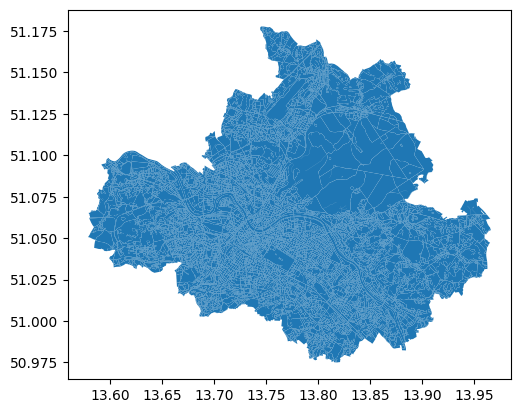

In [8]:
clipped_eua_dataset.plot()

In [9]:
pugs_class_list = [
    "Green urban areas",
    "Forests",
    "Herbaceous vegetation associations (natural grassland, moors...)",
]

In [10]:
clipped_eua_dataset["new_class"] = 0
clipped_eua_dataset.loc[
    clipped_eua_dataset["class_2018"].isin(pugs_class_list), "new_class"
] = 1

In [11]:
print_basic_info(clipped_eua_dataset)

Number of rows: 8660
Number of columns: 13


,country,fua_name,fua_code,code_2018,class_2018,prod_date,identifier,perimeter,area,comment,Pop2018,geometry,new_class
60948,DE,Dresden,DE009L2,31000,Forests,2020-09,61166-DE009L2,8594.180156,755622.324881,None,0,"MULTIPOLYGON (((13.7991 50.9777, 13.79909 50.9...",1
26186,DE,Dresden,DE009L2,11210,Discontinuous dense urban fabric (S.L. : 50% -...,2020-09,8563-DE009L2,470.740149,11549.482881,None,32,"POLYGON ((13.79405 50.97803, 13.7938 50.97796,...",0
26527,DE,Dresden,DE009L2,12100,"Industrial, commercial, public, military and p...",2020-09,27413-DE009L2,426.572356,7374.405198,None,2,"POLYGON ((13.87359 50.98337, 13.87393 50.98332...",0


In [12]:
cropped_data = clipped_eua_dataset.to_crs(epsg=crs)

In [13]:
output_path = config["paths"]["eua_pugs_path"]

if not os.path.exists(os.path.dirname(output_path)):
    os.makedirs(os.path.dirname(output_path))

# Save the cropped data
cropped_data[cropped_data["new_class"] == 1].to_file(
    output_path, driver="GeoJSON"
)

# 3. Extract Park (I type) from Recreational and leisure areas dataset

In [14]:
leisure_gdf = gpd.read_file(config["paths"]["leisure_area_path"])

In [15]:
parks_gdf = leisure_gdf[
    leisure_gdf["sst_liste"] == "I   Parkanlagen, Zoo, Botanischer Garten"
]

In [16]:
print_basic_info(parks_gdf)

Number of rows: 89
Number of columns: 15


,gml_id,blocknr,obj_id,kattime_brutto,kattime,sst_liste,sst_lv_2_liste,sst_lv_3_liste,deskn1_liste,desk2,desk3,deskn1,flaeche,aend,geometry
2,L1263.919778,945120,21088a,895546,919778,"I Parkanlagen, Zoo, Botanischer Garten",I1 Parks,I11 Parks,VSG-Grad 10 - 20 %,I1,I11,1,6047.863237,2024-04-24,"POLYGON ((408818.015 5653833.579, 408807.323 5..."
3,L1263.916183,933210,5578a,891283,916183,"I Parkanlagen, Zoo, Botanischer Garten",I1 Parks,I11 Parks,unversiegelt (naturnahe Flächen mit VSG-Grad k...,I1,I11,0,16330.601040,2018-12-10,"POLYGON ((408887.478 5653977.017, 408887.281 5..."
17,L1263.910452,036070,130a,891992,910452,"I Parkanlagen, Zoo, Botanischer Garten",I1 Parks,I11 Parks,VSG-Grad 10 - 20 %,I1,I11,1,18189.652296,2022-05-20,"POLYGON ((412210.427 5655508.714, 412258.965 5..."


In [17]:
output_path = config["paths"]["parks_i_type_path"]

if not os.path.exists(os.path.dirname(output_path)):
    os.makedirs(os.path.dirname(output_path))

parks_gdf.to_file(
    output_path, driver="GeoJSON"
)